# Natural & infrastructural barriers from OSM

Downloads roads, railways and rivers from OpenStreetMap for a circular area
around given coordinates with defined radius in kms.

In [82]:
# !pip3.12 install osmnx
# !pip3.12 install matplotlib

In [83]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt

In [84]:
center = (53.09181, -2.43531)  # (lat, lon)
radius_m = 10_000              # 10 km

In [85]:
# Roads: motorway / trunk / primary / secondary / tertiary + their _link (junction) variants
road_filter = (
    '["highway"~"motorway|trunk|primary|secondary|tertiary'
    '|motorway_link|trunk_link|primary_link|secondary_link|tertiary_link"]'
)
roads_graph = ox.graph_from_point(center, dist=radius_m, custom_filter=road_filter, simplify=True)
roads = ox.graph_to_gdfs(roads_graph, nodes=False, edges=True).reset_index()
# graph_to_gdfs can return list-valued 'highway' on simplified edges -> flatten for inspection
if "highway" in roads.columns:
    roads["highway_str"] = roads["highway"].apply(lambda v: v[0] if isinstance(v, list) else v)
    print(roads["highway_str"].value_counts())
print(f"roads: {len(roads)} segments")
roads.head()


highway_str
tertiary          542
trunk             313
primary           299
secondary         265
motorway_link      18
motorway           10
tertiary_link       8
trunk_link          6
secondary_link      2
primary_link        1
Name: count, dtype: int64
roads: 1464 segments


,u,v,key,osmid,highway,lanes,maxspeed,oneway,ref,reversed,length,bridge,geometry,junction,name,width,highway_str
0,219466,219516,0,"[142659648, 3128545, 3128551, 230599211, 14265...",motorway,3,70 mph,True,M6,False,7130.152915,yes,"LINESTRING (-2.33645 53.07321, -2.33731 53.074...",NaN,NaN,NaN,motorway
1,219474,9027192204,0,3042364,trunk,NaN,60 mph,False,NaN,False,55.639795,NaN,"LINESTRING (-2.33458 53.0682, -2.33477 53.0682...",circular,Barthomley Interchange,NaN,trunk
2,219474,9027192205,0,3042364,trunk,NaN,60 mph,False,NaN,True,14.151843,NaN,"LINESTRING (-2.33458 53.0682, -2.33447 53.0681...",circular,Barthomley Interchange,NaN,trunk
3,219474,16081558,0,6288251,trunk,NaN,70 mph,True,A500,False,148.218670,NaN,"LINESTRING (-2.33458 53.0682, -2.33502 53.0682...",NaN,NaN,NaN,trunk
4,219515,12863152,0,"[142659631, 142659632, 1102901553, 142659634, ...",motorway,3,70 mph,True,M6,False,7173.418459,yes,"LINESTRING (-2.33606 53.1368, -2.33583 53.1337...",NaN,NaN,NaN,motorway


In [86]:
# Railways: only actual lines (main / branch / industrial through-tracks),
# drop sidings, yards, spurs, crossovers and other service tracks.
railways = ox.features_from_point(
    center,
    tags={"railway": "rail"},   # exclude tram/subway/light_rail/narrow_gauge per request
    dist=radius_m,
)
railways = railways[railways.geom_type.isin(["LineString", "MultiLineString"])].copy()

# A 'service' tag means it's a service track (siding, yard, spur, crossover, ...).
# Main and branch lines have no 'service' tag at all -> keep only those.
if "service" in railways.columns:
    railways = railways[railways["service"].isna()]

railways = railways.reset_index()
print(f"railways: {len(railways)} segments")
if "usage" in railways.columns:
    print(railways["usage"].value_counts(dropna=False))
railways.head()


railways: 419 segments
usage
main      407
branch      8
NaN         4
Name: count, dtype: int64


,element,id,geometry,railway,name,ref,note,source,operator,electrified,...,cutting,tracks,service,railway:bidirectional,description,tunnel,tunnel:name,railway:preserved,designated_direction,embankment
0,way,4008850,"LINESTRING (-2.43994 53.10187, -2.44027 53.10247)",rail,West Coast Main Line,LEC5,NaN,NPE + GPX,Network Rail,contact_line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,way,4010111,"LINESTRING (-2.43937 53.09415, -2.43865 53.09401)",rail,North Wales Coast Line,CNH1,NaN,NaN,Network Rail,contact_line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,way,4010113,"LINESTRING (-2.54054 53.05292, -2.53858 53.054...",rail,Shrewsbury and Crewe Line,SYC,NaN,Bing,Network Rail,no,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,way,4010114,"LINESTRING (-2.43236 53.08893, -2.43227 53.08876)",rail,Crewe to Derby Line,LEC5,NaN,Bing,Network Rail,contact_line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,way,4711343,"LINESTRING (-2.43483 53.08066, -2.43464 53.08073)",rail,Shrewsbury and Crewe Line,SYC,NaN,Bing,Network Rail,contact_line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [87]:
# Rivers / streams: waterway=river|stream|canal|drain, plus natural=water polygons
rivers = ox.features_from_point(
    center,
    tags={"waterway": ["river", "stream", "canal", "drain"]},
    dist=radius_m,
)
rivers = rivers[rivers.geom_type.isin(["LineString", "MultiLineString"])].reset_index()
print(f"rivers: {len(rivers)} segments")
rivers.head()

rivers: 790 segments


,element,id,geometry,waterway,operator,operator:wikidata,lock,note,source,name,...,width,bridge:ref,ref,height,admin_level,boundary,VCNAME,VCNUMBER,fixme,maxheight
0,way,4727270,"LINESTRING (-2.44868 53.04645, -2.44842 53.046...",stream,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,way,4728274,"LINESTRING (-2.50957 53.043, -2.50969 53.04295...",stream,NaN,NaN,NaN,NaN,OS 1st provisional edition 1:25k,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,way,6630041,"LINESTRING (-2.54912 53.07962, -2.54896 53.079...",canal,Canal and River Trust,Q5030960,NaN,NaN,OS OPenData StreetView,Shropshire Union Canal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,way,6630045,"LINESTRING (-2.53565 53.06933, -2.53551 53.069...",canal,Canal and River Trust,Q5030960,NaN,NaN,NaN,Shropshire Union Canal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,way,23539933,"LINESTRING (-2.53578 53.0664, -2.53565 53.0664...",stream,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [88]:
# Forests: areal barriers (landuse=forest or natural=wood).
# Polygons, so no centerline step — just download and dissolve touching/overlapping pieces.
from shapely.ops import unary_union as _uu

forests = ox.features_from_point(
    center,
    tags={"landuse": "forest", "natural": "wood"},
    dist=radius_m,
)
forests = forests[forests.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

if not forests.empty:
    src_crs = forests.crs
    merged = _uu(forests.to_crs("EPSG:2180").geometry.values)
    parts = [merged] if merged.geom_type == "Polygon" else list(merged.geoms)
    forests_merged = gpd.GeoDataFrame({"geometry": parts}, crs="EPSG:2180").to_crs(src_crs)
else:
    forests_merged = forests.copy()

print(f"forests: {len(forests)} raw -> {len(forests_merged)} after dissolve")
forests_merged.head()


forests: 1021 raw -> 950 after dissolve


,geometry
0,"POLYGON ((-2.51061 53.00172, -2.51038 53.0019,..."
1,"POLYGON ((-2.51682 53.00184, -2.51631 53.00158..."
2,"POLYGON ((-2.5136 53.00289, -2.51349 53.003, -..."
3,"POLYGON ((-2.5169 53.00677, -2.51684 53.00688,..."
4,"POLYGON ((-2.52886 53.00551, -2.5289 53.00552,..."


In [89]:
# --- Merge parallel ways of the same class ---------------------------------
# Pipeline (per class):
#   1. buffer each line
#   2. dissolve all buffers -> one or more polygons
#   3. extract the centerline of each polygon -> one feature per polygon
#
# Requires:  pip install centerline
from shapely.ops import unary_union, linemerge
from shapely.geometry import MultiLineString
from centerline.geometry import Centerline
import pandas as pd

METRIC_CRS = "EPSG:2180"   # PL-1992, metric, suitable for Poland


def _flatten(v):
    return v[0] if isinstance(v, list) else v


def buffer_dissolve_centerline(gdf, class_col, buffer_dist, simplify_tol=2.0):
    """For each class in `class_col`:
       buffer lines -> dissolve -> centerline of every resulting polygon.
       One row per polygon. Input/output CRS preserved."""
    if gdf.empty:
        return gdf.copy()

    src_crs = gdf.crs
    g = gdf.to_crs(METRIC_CRS).copy()
    g[class_col] = g[class_col].apply(_flatten)

    rows = []
    for cls, sub in g.groupby(class_col):
        # 1 + 2: buffer + dissolve
        dissolved = unary_union(sub.geometry.buffer(buffer_dist).values)
        polys = [dissolved] if dissolved.geom_type == "Polygon" else list(dissolved.geoms)

        # 3: centerline per polygon
        for poly in polys:
            cl = Centerline(poly, interpolation_distance=buffer_dist).geometry
            if isinstance(cl, MultiLineString):
                cl = linemerge(cl)
            rows.append({class_col: cls, "geometry": cl.simplify(simplify_tol)})

    return gpd.GeoDataFrame(rows, crs=METRIC_CRS).to_crs(src_crs)


def merge_by_class(gdf, class_col, buffer_table):
    """Run buffer/dissolve/centerline per class with a class-specific buffer."""
    parts = []
    for cls, dist in buffer_table.items():
        sub = gdf[gdf[class_col].apply(_flatten) == cls]
        if sub.empty:
            continue
        parts.append(buffer_dissolve_centerline(sub[[class_col, "geometry"]], class_col, dist))
    if not parts:
        return gdf.iloc[0:0]
    return gpd.GeoDataFrame(pd.concat(parts, ignore_index=True), crs=gdf.crs)


# Per-class buffer widths (metres). Half the spacing between parallel ways
# of the same class, so two carriageways / two tracks merge but adjacent
# different ways don't.
ROAD_BUFFER_M = {
    "motorway": 55, "motorway_link": 100,
    "trunk":    50, "trunk_link":    100,
    "primary":  55, "primary_link":  75,
    "secondary": 45, "secondary_link": 75,
    "tertiary": 40, "tertiary_link":  75,
}
RAIL_BUFFER_M  = {"rail": 50}
RIVER_BUFFER_M = {
    "river":  45,   # may have multiple braided channels mapped separately
    "canal":  35,
    "stream":  35,
}


roads_merged    = merge_by_class(roads,    "highway",  ROAD_BUFFER_M)
railways_merged = merge_by_class(railways, "railway",  RAIL_BUFFER_M)
rivers_merged   = merge_by_class(rivers,   "waterway", RIVER_BUFFER_M)

print(f"roads:    {len(roads)} -> {len(roads_merged)} features after merge")
print(f"railways: {len(railways)} -> {len(railways_merged)} features after merge")
print(f"rivers:   {len(rivers)} -> {len(rivers_merged)} features after merge")


roads:    1464 -> 54 features after merge
railways: 419 -> 1 features after merge
rivers:   790 -> 106 features after merge


In [90]:
# --- Unified barrier layer -------------------------------------------------
# Stack roads / rails / rivers together, buffer & dissolve all types as one,
# extract centerline of each resulting polygon, then smooth.

UNIFIED_BUFFER_M = 25   # one buffer width for the unified layer


def chaikin(line, iterations=2):
    """Chaikin corner-cutting smoothing for a LineString."""
    from shapely.geometry import LineString
    coords = list(line.coords)
    for _ in range(iterations):
        new = [coords[0]]
        for i in range(len(coords) - 1):
            p, q = coords[i], coords[i + 1]
            new.append((0.75 * p[0] + 0.25 * q[0], 0.75 * p[1] + 0.25 * q[1]))
            new.append((0.25 * p[0] + 0.75 * q[0], 0.25 * p[1] + 0.75 * q[1]))
        new.append(coords[-1])
        coords = new
    return LineString(coords)


def smooth(geom, iterations=2):
    from shapely.geometry import LineString
    if isinstance(geom, LineString):
        return chaikin(geom, iterations)
    # MultiLineString -> smooth each part
    return MultiLineString([chaikin(p, iterations) for p in geom.geoms])


# 1. stack the three layers (type label kept for reference)
def _tag(gdf, t):
    out = gdf[["geometry"]].copy()
    out["src"] = t
    return out

stacked = gpd.GeoDataFrame(
    pd.concat([_tag(roads_merged, "road"),
               _tag(railways_merged, "rail"),
               _tag(rivers_merged, "river")], ignore_index=True),
    crs=roads_merged.crs,
).to_crs(METRIC_CRS)

# 2 + 3. buffer & dissolve everything together
dissolved = unary_union(stacked.geometry.buffer(UNIFIED_BUFFER_M).values)
polys = [dissolved] if dissolved.geom_type == "Polygon" else list(dissolved.geoms)

# 4. centerline per polygon
# 5. simplify + Chaikin smoothing
rows = []
for poly in polys:
    cl = Centerline(poly, interpolation_distance=UNIFIED_BUFFER_M).geometry
    if isinstance(cl, MultiLineString):
        cl = linemerge(cl)
    cl = cl.simplify(2.0)        # drop voronoi jitter
    cl = smooth(cl, iterations=2)  # Chaikin
    rows.append({"geometry": cl})

barriers_merged = gpd.GeoDataFrame(rows, crs=METRIC_CRS).to_crs(roads_merged.crs)
print(f"unified barriers: {len(barriers_merged)} features")


unified barriers: 31 features


In [91]:
# --- Post-process: prune Voronoi dead-ends on the unified barrier layer ----
# A "branch" is the path from a degree-1 vertex back to the nearest junction
# (degree >= 3). Iteratively drop any branch shorter than MIN_BRANCH_M.
import networkx as nx
from shapely.geometry import LineString, MultiLineString, Point

# 2-3x the buffer width works well: anything shorter is almost certainly an
# artifact reaching into a corner of the buffered polygon, not a real branch.
MIN_BRANCH_M = 5 * UNIFIED_BUFFER_M


def prune_dead_ends(geom, min_branch_length):
    if geom.is_empty:
        return geom
    parts = [geom] if isinstance(geom, LineString) else list(geom.geoms)

    G = nx.MultiGraph()
    for ls in parts:
        c = list(ls.coords)
        for a, b in zip(c[:-1], c[1:]):
            G.add_edge(a, b, length=Point(a).distance(Point(b)))

    while True:
        leaves = [n for n in G.nodes if G.degree(n) == 1]
        if not leaves:
            break
        removed = False
        for leaf in leaves:
            if leaf not in G:        # may already have been pruned this pass
                continue
            path, length, prev = [leaf], 0.0, None
            cur = leaf
            while True:
                nbrs = [n for n in G.neighbors(cur) if n != prev]
                if not nbrs:
                    break
                nxt = nbrs[0]
                length += G[cur][nxt][0]["length"]
                path.append(nxt)
                prev, cur = cur, nxt
                if G.degree(cur) != 2 or length >= min_branch_length:
                    break
            if length < min_branch_length:
                for a, b in zip(path[:-1], path[1:]):
                    G.remove_edge(a, b, key=list(G[a][b].keys())[0])
                for n in path[:-1]:
                    if n in G and G.degree(n) == 0:
                        G.remove_node(n)
                removed = True
        if not removed:
            break

    if G.number_of_edges() == 0:
        return MultiLineString()
    return linemerge(unary_union([LineString([u, v]) for u, v in G.edges()]))


# Project to metric CRS for length-based pruning, then back.
src_crs = barriers_merged.crs
_bm = barriers_merged.to_crs(METRIC_CRS).copy()
_bm["geometry"] = _bm.geometry.apply(lambda g: prune_dead_ends(g, MIN_BRANCH_M))
# Drop rows whose entire geometry was a single short branch.
_bm = _bm[~_bm.geometry.is_empty].reset_index(drop=True)
barriers_merged = _bm.to_crs(src_crs)

print(f"after pruning (min branch {MIN_BRANCH_M} m): {len(barriers_merged)} features")


after pruning (min branch 125 m): 23 features


In [99]:
# --- Zones: split AOI rectangle by barriers, then merge tiny slivers --------
from shapely.geometry import box, Point
from shapely.ops import polygonize

MIN_ZONE_AREA_M2 = 15_000   # 0.25 km² - anything smaller gets absorbed

# 1. Build AOI rectangle = bounding box of the 10 km buffer around `center`
center_pt = gpd.GeoSeries([Point(center[1], center[0])], crs="EPSG:4326")
buffer_circle = center_pt.to_crs(METRIC_CRS).buffer(radius_m).iloc[0]
aoi_rect = box(*buffer_circle.bounds)        # 20 km x 20 km square in EPSG:2180

# 2. Cut the rectangle with the pruned unified barrier lines
barrier_lines = unary_union(
    barriers_merged.to_crs(METRIC_CRS).geometry.values
).intersection(aoi_rect)

split_network = unary_union([aoi_rect.boundary, barrier_lines])
zones = [p for p in polygonize(split_network) if aoi_rect.contains(p.representative_point())]
zones_gdf = gpd.GeoDataFrame({"geometry": zones}, crs=METRIC_CRS)
zones_gdf["area_m2"] = zones_gdf.geometry.area
print(f"initial zones: {len(zones_gdf)} "
      f"(min {zones_gdf.area_m2.min():.0f} m², max {zones_gdf.area_m2.max():.0f} m²)")


def merge_small_zones(gdf, min_area):
    """Iteratively merge each zone smaller than `min_area` into the neighbour
    with which it shares the longest common border."""
    gdf = gdf.copy().reset_index(drop=True)
    while True:
        gdf["area_m2"] = gdf.geometry.area
        small = gdf[gdf.area_m2 < min_area]
        if small.empty:
            break
        i = small["area_m2"].idxmin()              # absorb smallest first
        small_geom = gdf.loc[i, "geometry"]
        small_boundary = small_geom.boundary

        # neighbours = zones whose boundary intersects this one (share an edge)
        candidates_idx = gdf.index[gdf.geometry.intersects(small_geom)].difference([i])
        if len(candidates_idx) == 0:
            gdf = gdf.drop(index=i).reset_index(drop=True)
            continue

        shared = gdf.loc[candidates_idx, "geometry"].apply(
            lambda g: small_boundary.intersection(g.boundary).length
        )
        if shared.max() == 0:
            gdf = gdf.drop(index=i).reset_index(drop=True)
            continue

        best_j = shared.idxmax()
        gdf.loc[best_j, "geometry"] = unary_union(
            [gdf.loc[best_j, "geometry"], small_geom]
        )
        gdf = gdf.drop(index=i).reset_index(drop=True)

    gdf["area_m2"] = gdf.geometry.area
    return gdf


zones_gdf = merge_small_zones(zones_gdf, MIN_ZONE_AREA_M2)
zones_merged = zones_gdf.to_crs("EPSG:4326")
print(f"after merging <{MIN_ZONE_AREA_M2/1e6:.2f} km² zones: {len(zones_merged)} zones "
      f"(min {zones_gdf.area_m2.min():.0f} m², max {zones_gdf.area_m2.max():.0f} m²)")


initial zones: 394 (min 1225 m², max 23057062 m²)
after merging <0.01 km² zones: 338 zones (min 15943 m², max 23061479 m²)


In [100]:
# Save all layers into a single GeoPackage. List-valued columns are stringified
# because GPKG (SQLite) only stores scalar attribute types.
GPKG_PATH = "osm_barriers.gpkg"


def to_gpkg(gdf, path, layer):
    safe = gdf.copy()
    for col in safe.columns:
        if col == "geometry":
            continue
        if safe[col].apply(lambda v: isinstance(v, list)).any():
            safe[col] = safe[col].astype(str)
    safe.to_file(path, layer=layer, driver="GPKG")


to_gpkg(roads_merged,    GPKG_PATH, "roads")
to_gpkg(railways_merged, GPKG_PATH, "railways")
to_gpkg(rivers_merged,   GPKG_PATH, "rivers")
to_gpkg(forests_merged,  GPKG_PATH, "forests")
to_gpkg(barriers_merged, GPKG_PATH, "barriers")
to_gpkg(zones_merged,    GPKG_PATH, "zones")
print(f"wrote {GPKG_PATH} with layers: roads, railways, rivers, forests, barriers, zones")


wrote osm_barriers.gpkg with layers: roads, railways, rivers, forests, barriers, zones


C:\Users\Witold\AppData\Local\Temp\ipykernel_14616\1359256084.py:11: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


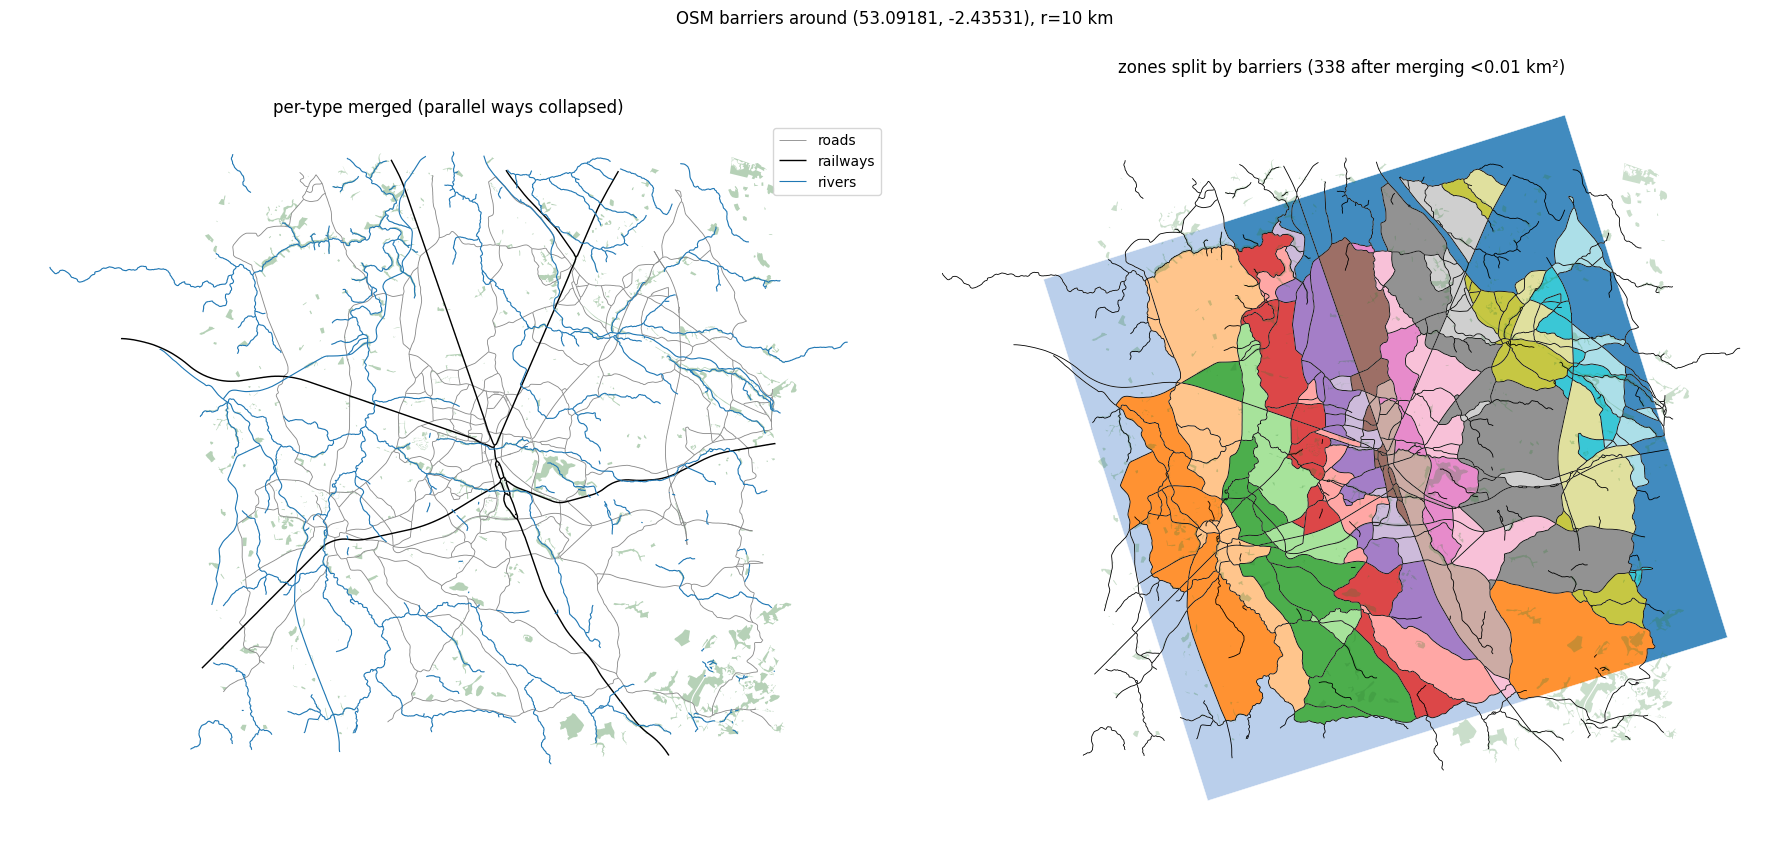

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Per-type merged layers (forests as filled polygons underneath)
ax = axes[0]
forests_merged.plot(ax=ax,  color="#2e7d32", alpha=0.35, edgecolor="none", label="forests")
roads_merged.plot(ax=ax,    color="#888888", linewidth=0.6, label="roads")
railways_merged.plot(ax=ax, color="black",   linewidth=1.0, label="railways")
rivers_merged.plot(ax=ax,   color="#1f77b4", linewidth=0.8, label="rivers")
ax.set_title("per-type merged (parallel ways collapsed)")
ax.set_axis_off()
ax.legend()

# Zones split by unified barriers, each filled with a random colour
ax = axes[1]
zones_merged.plot(
    ax=ax,
    column=zones_merged.index, cmap="tab20",
    edgecolor="white", linewidth=0.4, alpha=0.85,
)
barriers_merged.plot(ax=ax, color="black", linewidth=0.6)
forests_merged.plot(ax=ax, color="#2e7d32", alpha=0.25, edgecolor="none")
ax.set_title(f"zones split by barriers ({len(zones_merged)} after merging <"
             f"{MIN_ZONE_AREA_M2/1e6:.2f} km²)")
ax.set_axis_off()

plt.suptitle(f"OSM barriers around {center}, r={radius_m/1000:g} km")
plt.tight_layout()
plt.show()
